# Test Generated SIMNRA Data

This notebook reloads an already dumped multilayer dataset, randomly selects 1000 samples from the `layers_10` case, recalculates the spectra with SIMNRA, and compares the dumped spectra to the fresh SIMNRA output.

Per-sample disagreement is measured as the mean over channels of

`chi2 = (old - new)^2 / (old + 1)`

Any sample/method pair above `chi2_min` is printed as soon as that batch finishes.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import math

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
if (cwd / "ibamlkit").exists():
    repo_root = cwd
elif (cwd.parent / "ibamlkit").exists():
    repo_root = cwd.parent
else:
    raise RuntimeError(f"Could not locate repo root from {cwd}")

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from ibamlkit.data import DatasetBatchReader
from ibamlkit.validation import SIMNRABatchSimulator

print("Repo root:", repo_root)

Repo root: D:\IBAMLKit


In [2]:
dataset_dir = repo_root / "examples" / "datasets" /  "multilayer_7_elements_seed_1" / "layers_10"
method_names = ["NRA", "RBS"]
random_seed = 123
sample_count_to_test = 1000
chi2_min = 1.0
nthreads = 90
batch_size = 90

reader = DatasetBatchReader()

def require_dataset_dir(path: Path) -> Path:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if not path.is_dir():
        raise NotADirectoryError(path)
    return path

def effective_length(lengths_dict, method_name: str, index: int, padded_width: int) -> int:
    if lengths_dict is None:
        return int(padded_width)
    return int(lengths_dict[method_name][index])

def padded_vector(row: np.ndarray, length: int, target_length: int) -> np.ndarray:
    out = np.zeros((target_length,), dtype=np.float64)
    if length > 0:
        out[:length] = np.asarray(row[:length], dtype=np.float64)
    return out

def compare_one_spectrum(old_row, old_length: int, new_row, new_length: int) -> tuple[float, int]:
    compare_length = max(int(old_length), int(new_length))
    old_vec = padded_vector(old_row, int(old_length), compare_length)
    new_vec = padded_vector(new_row, int(new_length), compare_length)
    chi2_vector = (old_vec - new_vec) ** 2 / (old_vec + 1.0)
    return float(np.mean(chi2_vector)), compare_length

require_dataset_dir(dataset_dir)
paths = reader.collect_dataset_paths(dataset_dir)
print("Dataset directory:", dataset_dir)
print("Dataset shards:", len(paths))

Dataset directory: D:\IBAMLKit\examples\datasets\multilayer_7_elements_seed_1\layers_10
Dataset shards: 1


In [3]:
dataset = reader.load_many(paths)


In [5]:
print(dataset.input_spec)

DatasetInputSpec(methods=[MethodSpec(name='NRA', reference_file='D:/IBAMLKit/xnra/Ref_all_nra_nopu_703.xnra', file_type='SIMNRA', metadata={}), MethodSpec(name='RBS', reference_file='D:/IBAMLKit/xnra/Ref_all_rbs_nopu_703.xnra', file_type='SIMNRA', metadata={})], layer_species=[LayerSpeciesSpec(layer_index=1, element='Li', isotope=''), LayerSpeciesSpec(layer_index=1, element='C', isotope=''), LayerSpeciesSpec(layer_index=1, element='O', isotope=''), LayerSpeciesSpec(layer_index=1, element='F', isotope=''), LayerSpeciesSpec(layer_index=1, element='Si', isotope=''), LayerSpeciesSpec(layer_index=1, element='P', isotope=''), LayerSpeciesSpec(layer_index=1, element='Cu', isotope=''), LayerSpeciesSpec(layer_index=2, element='Li', isotope=''), LayerSpeciesSpec(layer_index=2, element='C', isotope=''), LayerSpeciesSpec(layer_index=2, element='O', isotope=''), LayerSpeciesSpec(layer_index=2, element='F', isotope=''), LayerSpeciesSpec(layer_index=2, element='Si', isotope=''), LayerSpeciesSpec(laye

In [ ]:
dataset = reader.load_many(paths)
n_layers = int(dataset.input_spec.generation_info.get("n_layers", 0))
if n_layers != 10:
    raise RuntimeError(f"Expected n_layers=10, got {n_layers}")

available_methods = [method.name for method in dataset.input_spec.methods]
missing_methods = [name for name in method_names if name not in available_methods]
if missing_methods:
    raise RuntimeError(f"Requested methods not present in dataset: {missing_methods}")

total_samples = dataset.sample_count
take = min(int(sample_count_to_test), total_samples)
rng = np.random.default_rng(random_seed)
selected_indices = rng.choice(total_samples, size=take, replace=False)

sample_ids = dataset.sample_ids if dataset.sample_ids is not None else [f"sample-{i:08d}" for i in range(total_samples)]
selected_open = np.asarray(dataset.open_parameter_values[selected_indices], dtype=np.float32)

chi2_by_method = {
    method_name: np.full((take,), np.nan, dtype=np.float64)
    for method_name in method_names
}
length_mismatch_count = {method_name: 0 for method_name in method_names}
failing_rows: list[dict[str, object]] = []

simulator = SIMNRABatchSimulator(dataset.input_spec)
try:
    batch_total = math.ceil(take / batch_size)
    for batch_index, start in enumerate(range(0, take, batch_size), start=1):
        stop = min(start + batch_size, take)
        batch_global_indices = selected_indices[start:stop]
        batch_open = selected_open[start:stop]
        result = simulator.simulate_batch(batch_open, nthreads=nthreads)

        for local_row, dataset_row in enumerate(batch_global_indices):
            sample_id = sample_ids[int(dataset_row)]
            for method_name in method_names:
                old_matrix = dataset.spectra[method_name]
                new_matrix = result.spectra[method_name]
                old_length = effective_length(
                    dataset.spectra_lengths,
                    method_name,
                    int(dataset_row),
                    old_matrix.shape[1],
                )
                new_length = effective_length(
                    result.spectra_lengths,
                    method_name,
                    int(local_row),
                    new_matrix.shape[1],
                )
                if old_length != new_length:
                    length_mismatch_count[method_name] += 1
                chi2_value, compared_length = compare_one_spectrum(
                    old_matrix[int(dataset_row)],
                    old_length,
                    new_matrix[int(local_row)],
                    new_length,
                )
                chi2_by_method[method_name][start + local_row] = chi2_value
                if chi2_value > chi2_min:
                    row = {
                        "sample_index": int(dataset_row),
                        "sample_id": str(sample_id),
                        "method": method_name,
                        "chi2": chi2_value,
                        "old_length": int(old_length),
                        "new_length": int(new_length),
                        "compared_length": int(compared_length),
                    }
                    failing_rows.append(row)
                    print(
                        f"[FAIL] batch {batch_index}/{batch_total} | "
                        f"sample_index={row['sample_index']} | sample_id={row['sample_id']} | "
                        f"method={row['method']} | chi2={row['chi2']:.6f} | "
                        f"old_len={row['old_length']} | new_len={row['new_length']}"
                    )

        print(f"Finished batch {batch_index}/{batch_total} ({stop}/{take} samples)")
finally:
    simulator.close()

print()
print(f"Tested {take} random samples from n_layers={n_layers} with nthreads={nthreads}")
for method_name in method_names:
    values = chi2_by_method[method_name]
    fail_count = int(np.sum(values > chi2_min))
    print(
        f"{method_name}: mean={float(np.nanmean(values)):.6f}, "
        f"median={float(np.nanmedian(values)):.6f}, "
        f"max={float(np.nanmax(values)):.6f}, "
        f"fails={fail_count}, "
        f"length_mismatches={length_mismatch_count[method_name]}"
    )

if failing_rows:
    failing_rows = sorted(failing_rows, key=lambda row: float(row["chi2"]), reverse=True)
    print("\nWorst failures:")
    for row in failing_rows[:20]:
        print(row)
else:
    print("\nNo sample exceeded chi2_min.")

[FAIL] batch 1/12 | sample_index=64051 | sample_id=layers-10-064051 | method=NRA | chi2=5205052709.167613 | old_len=656 | new_len=653
[FAIL] batch 1/12 | sample_index=46058 | sample_id=layers-10-046058 | method=NRA | chi2=662844260.564009 | old_len=708 | new_len=744
[FAIL] batch 1/12 | sample_index=33144 | sample_id=layers-10-033144 | method=NRA | chi2=60497875776.728897 | old_len=744 | new_len=730
[FAIL] batch 1/12 | sample_index=46349 | sample_id=layers-10-046349 | method=NRA | chi2=2948801414.049115 | old_len=544 | new_len=744
[FAIL] batch 1/12 | sample_index=93482 | sample_id=layers-10-093482 | method=NRA | chi2=5974435348.310433 | old_len=741 | new_len=666
[FAIL] batch 1/12 | sample_index=30183 | sample_id=layers-10-030183 | method=NRA | chi2=212530640.668619 | old_len=744 | new_len=742
[FAIL] batch 1/12 | sample_index=26554 | sample_id=layers-10-026554 | method=NRA | chi2=114427730089918.796875 | old_len=744 | new_len=744
[FAIL] batch 1/12 | sample_index=1590 | sample_id=layers-1

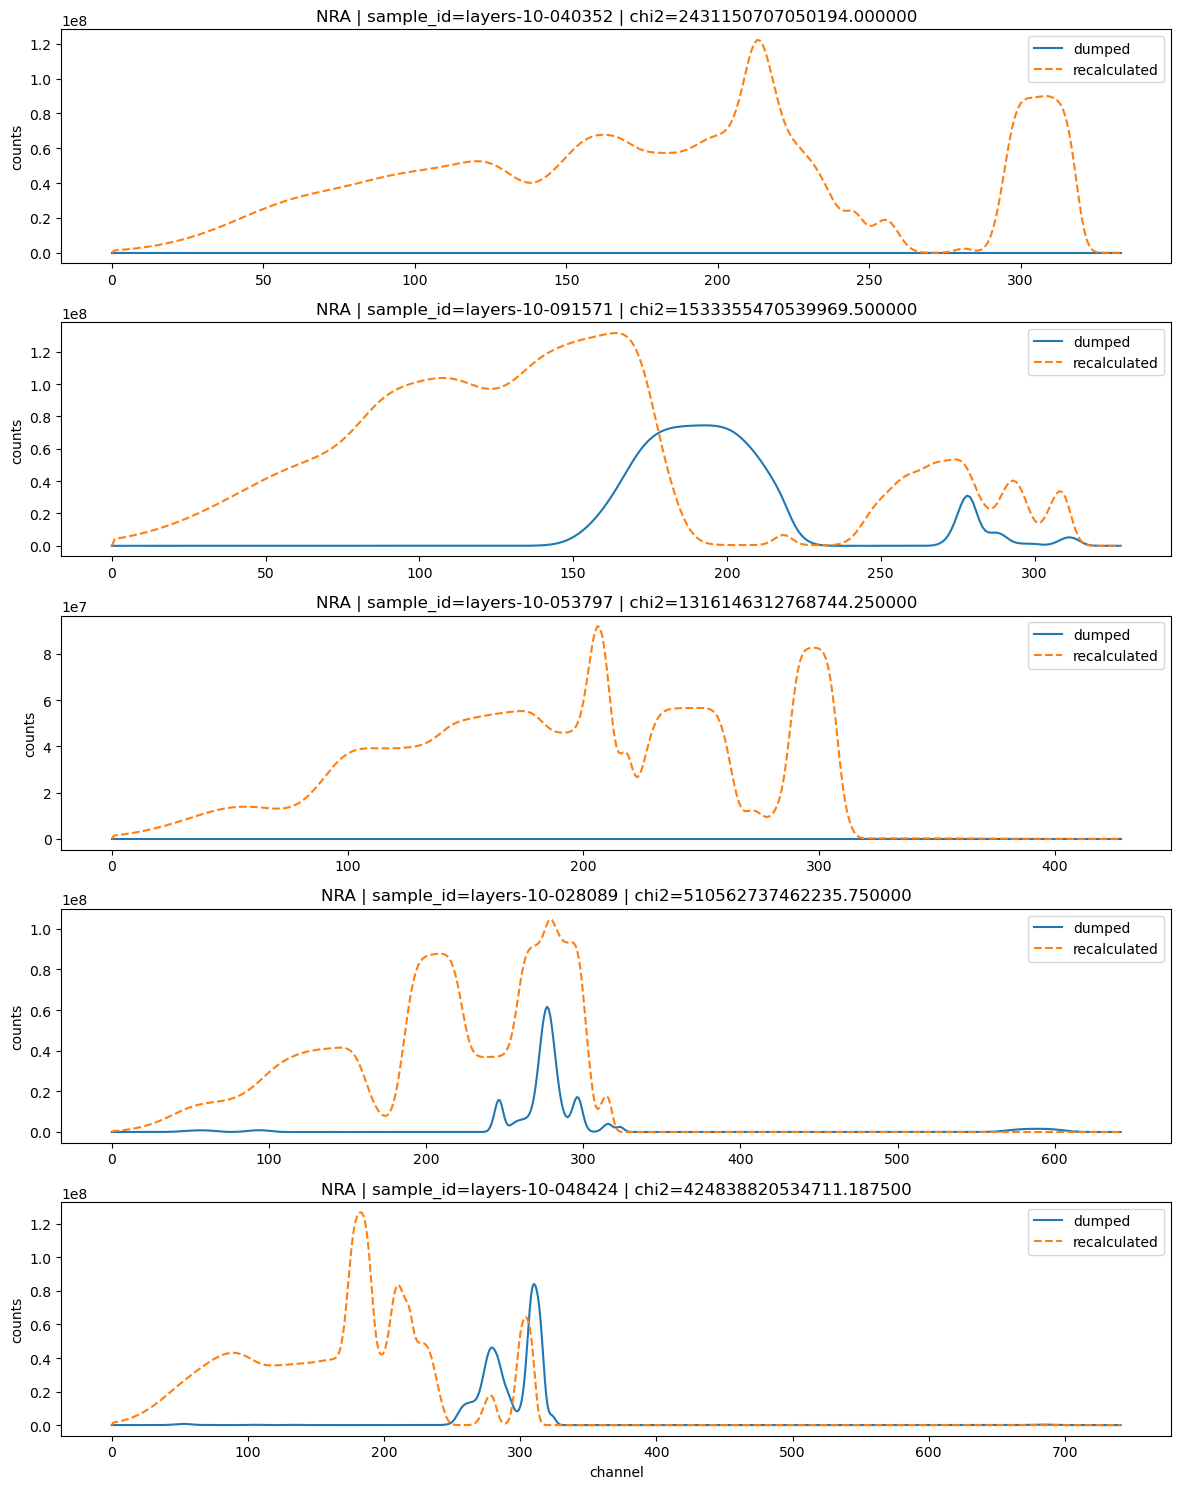

In [6]:
plot_method = "NRA"
n_plot = 5

method_failures = [row for row in failing_rows if row["method"] == plot_method]
if not method_failures:
    print(f"No failing rows for {plot_method}")
else:
    selected_failures = method_failures[:n_plot]
    simulator = SIMNRABatchSimulator(dataset.input_spec)
    try:
        rows = np.asarray([int(row["sample_index"]) for row in selected_failures], dtype=np.int32)
        open_values = np.asarray(dataset.open_parameter_values[rows], dtype=np.float32)
        result = simulator.simulate_batch(open_values, nthreads=min(nthreads, len(rows)))
    finally:
        simulator.close()

    fig, axes = plt.subplots(len(selected_failures), 1, figsize=(12, 3 * len(selected_failures)), sharex=False)
    if len(selected_failures) == 1:
        axes = np.asarray([axes])

    for ax, row, dataset_row, local_row in zip(axes, selected_failures, rows, range(len(rows))):
        old_length = effective_length(dataset.spectra_lengths, plot_method, int(dataset_row), dataset.spectra[plot_method].shape[1])
        new_length = effective_length(result.spectra_lengths, plot_method, int(local_row), result.spectra[plot_method].shape[1])
        compare_length = max(old_length, new_length)
        old_vec = padded_vector(dataset.spectra[plot_method][int(dataset_row)], old_length, compare_length)
        new_vec = padded_vector(result.spectra[plot_method][int(local_row)], new_length, compare_length)
        ax.plot(old_vec, label="dumped")
        ax.plot(new_vec, linestyle="--", label="recalculated")
        ax.set_title(f"{plot_method} | sample_id={row['sample_id']} | chi2={row['chi2']:.6f}")
        ax.set_ylabel("counts")
        ax.legend()

    axes[-1].set_xlabel("channel")
    plt.tight_layout()
    plt.show()